In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import json
import random
import torch
from datasets import load_dataset
from sentence_transformers.evaluation import InformationRetrievalEvaluator
from sentence_transformers import SentenceTransformer
import sentence_transformers.util as util

# Monkey patch the cos_sim function to ensure device consistency
# original_cos_sim = util.cos_sim

# def patched_cos_sim(a, b):
#     """Patched cosine similarity that ensures tensors are on the same device"""
#     if hasattr(a, 'device') and hasattr(b, 'device'):
#         if a.device != b.device:
#             # Move b to the same device as a
#             b = b.to(a.device)
#     return original_cos_sim(a, b)

# # Apply the patch
# util.cos_sim = patched_cos_sim

# Define the device to use
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
ks = [1, 3, 5, 10]

models = {
    "modernbert-embed-base": "nomic-ai/modernbert-embed-base",
    "nasa-smd-ibm-st-v2": "nasa-impact/nasa-smd-ibm-st-v2",
    "indus-sde-st-v0.1": "nasa-impact/indus-sde-st-v0.1"
}

corpus = load_dataset("nasa-impact/nasa-smd-IR-benchmark", data_files="https://huggingface.co/datasets/nasa-impact/nasa-smd-IR-benchmark/resolve/main/corpus.jsonl", split="train")
queries = load_dataset("nasa-impact/nasa-smd-IR-benchmark", data_files="https://huggingface.co/datasets/nasa-impact/nasa-smd-IR-benchmark/resolve/main/queries.jsonl", split="train")
relevant_docs_data = load_dataset("nasa-impact/nasa-smd-IR-benchmark", split="test")


corpus = { row["_id"]: row["text"] for i, row in enumerate(corpus)}
queries = { row["_id"]: row["text"] for row in queries }
relevant_docs_data = relevant_docs_data.to_pandas().groupby("query-id")['corpus-id'].apply(set).to_dict()
relevant_docs_data = {str(k): {str(item) for item in v} for k, v in relevant_docs_data.items()}


# for testing only
relevent_docs = set([str(i) for k, v in relevant_docs_data.items() for i in v])
corpus = {k: v for k, v in corpus.items() if k in relevent_docs}




evaluator = InformationRetrievalEvaluator(
                queries=queries,
                corpus=corpus,
                relevant_docs=relevant_docs_data,
                name="nasa_ir_evaluator",
                batch_size=8,
                mrr_at_k=ks,
                ndcg_at_k=ks,
                accuracy_at_k=ks,
                precision_recall_at_k=ks,
                map_at_k=ks,
                show_progress_bar=True,
                # convert_to_tensor=True,      # ensure corpus embeddings are torch.Tensors
                write_csv=True,
            )

all_results = {}

Using device: cuda:0


In [3]:
for model_name, model_path in models.items():
    print(f"Evaluating model: {model_name}")
    
    # Ensure CUDA context is properly set
    if device.startswith('cuda'):
        torch.cuda.set_device(device)
    
    model = SentenceTransformer(model_path, device=device)
    
    # Double-check model is on correct device
    model = model.to(device)
    
    results = evaluator(model)
    all_results[model_name] = results

    print(results)
    
    # Clean up
    del model
    if device.startswith('cuda'):
        torch.cuda.empty_cache()

Evaluating model: modernbert-embed-base


Batches:   0%|          | 0/50 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/21 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [00:09<00:00,  9.12s/it]


...

Batches:   0%|          | 0/50 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/21 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [00:05<00:00,  5.81s/it]

{'nasa_ir_evaluator_cosine_accuracy@1': 0.8140703517587939, 'nasa_ir_evaluator_cosine_accuracy@3': 0.9170854271356784, 'nasa_ir_evaluator_cosine_accuracy@5': 0.9371859296482412, 'nasa_ir_evaluator_cosine_accuracy@10': 0.9623115577889447, 'nasa_ir_evaluator_cosine_precision@1': 0.8140703517587939, 'nasa_ir_evaluator_cosine_precision@3': 0.3056951423785595, 'nasa_ir_evaluator_cosine_precision@5': 0.18743718592964823, 'nasa_ir_evaluator_cosine_precision@10': 0.09623115577889446, 'nasa_ir_evaluator_cosine_recall@1': 0.8140703517587939, 'nasa_ir_evaluator_cosine_recall@3': 0.9170854271356784, 'nasa_ir_evaluator_cosine_recall@5': 0.9371859296482412, 'nasa_ir_evaluator_cosine_recall@10': 0.9623115577889447, 'nasa_ir_evaluator_cosine_ndcg@1': 0.8140703517587939, 'nasa_ir_evaluator_cosine_ndcg@3': 0.8754469663496073, 'nasa_ir_evaluator_cosine_ndcg@5': 0.8838835617338019, 'nasa_ir_evaluator_cosine_ndcg@10': 0.892078955919419, 'nasa_ir_evaluator_cosine_mrr@1': 0.8140703517587939, 'nasa_ir_evaluat

# generating plots

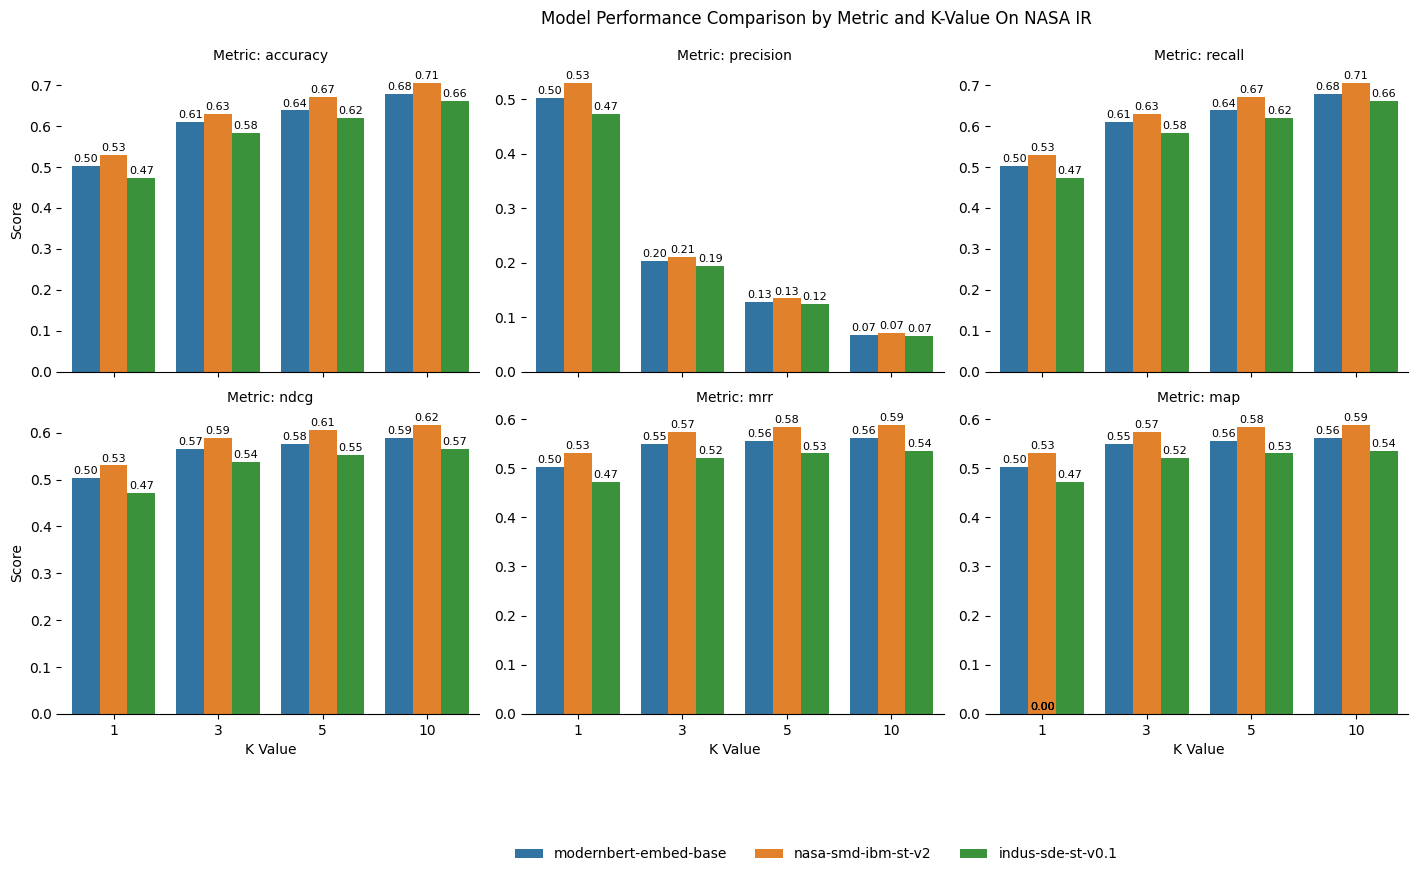

--- Data Table ---
                    model     metric   k     value
0   modernbert-embed-base   accuracy   1  0.502513
1   modernbert-embed-base   accuracy   3  0.610553
2   modernbert-embed-base   accuracy   5  0.638191
3   modernbert-embed-base   accuracy  10  0.678392
4   modernbert-embed-base  precision   1  0.502513
5   modernbert-embed-base  precision   3  0.203518
6   modernbert-embed-base  precision   5  0.127638
7   modernbert-embed-base  precision  10  0.067839
8   modernbert-embed-base     recall   1  0.502513
9   modernbert-embed-base     recall   3  0.610553
10  modernbert-embed-base     recall   5  0.638191
11  modernbert-embed-base     recall  10  0.678392
12  modernbert-embed-base       ndcg   1  0.502513
13  modernbert-embed-base       ndcg   3  0.565086
14  modernbert-embed-base       ndcg   5  0.576438
15  modernbert-embed-base       ndcg  10  0.589188
16  modernbert-embed-base        mrr   1  0.502513
17  modernbert-embed-base        mrr   3  0.549414
18  modernbe

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json


# open json file with results
results_file = "nasa_ir_eval_dump.json"
with open(results_file, 'r') as f:
    data = json.load(f)


# Process the data into a list of records
records = []
for model, metrics in data.items():
    for metric_name_full, value in metrics.items():
        parts = metric_name_full.split('@')
        k = int(parts[1])
        metric_name = parts[0].split('_')[-1]
        records.append({
            "model": model,
            "metric": metric_name,
            "k": k,
            "value": value
        })

# Create a pandas DataFrame
df = pd.DataFrame(records)

# Create the bar plot using seaborn's catplot for faceting
g = sns.catplot(
    data=df,
    x='k',
    y='value',
    hue='model',
    col='metric',
    kind='bar',
    col_wrap=3,
    sharey=False,
    height=4,
    aspect=1.2,
    legend_out=True
)

# Customize the plot with titles and labels
g.fig.suptitle('Model Performance Comparison by Metric and K-Value On NASA IR', y=1.03)
g.set_titles("Metric: {col_name}")
g.set_axis_labels("K Value", "Score")
g.despine(left=True)

# --- NEW: Add value labels on top of each bar ---
for ax in g.axes.flat:
    # Iterate through the bars in each subplot
    for p in ax.patches:
        # Get the height of the bar and format it to 2 decimal places
        value = f'{p.get_height():.2f}'
        # Define the position for the annotation
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        # Add the text to the plot
        ax.annotate(
            value,
            (x, y),
            ha='center',
            va='center',
            xytext=(0, 5), # 5 points vertical offset
            textcoords='offset points',
            fontsize=8
        )

# Move and format the legend
sns.move_legend(
    g, "lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=3,
    title=None,
    frameon=False,
)

# Adjust the bottom of the figure to make space for the legend
g.fig.subplots_adjust(bottom=0.15)


# Display the plot
plt.show()

# --- Table Generation ---
print("--- Data Table ---")
# Using to_string() to ensure the full table is printed
print(df.to_string())

In [ ]:
/rhome/sawale/indus_traning/sentense_transformers/eval/artifacts/model-qr3ln5om:v1